Note: Illegal Audio-MPEG-Header 0x3934372c at offset 1604160.
Note: Trying to resync...
/var/folders/jp/_n1yy6w143x6rxr2gt1kr6d00000gn/T/ipykernel_35534/4134237042.py:6: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load("sample1.mp3", sr=None)
/Users/bibekjoshi01/Drive X/Major-Project/venv/lib/python3.12/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
Note: Skipped 1024 bytes in input.
[src/libmpg123/parse.c:wetwork():1349] error: Giving up resync after 1024 bytes - your stream is not nice... (maybe increasing resync limit could help).


Spectrogram shape: (1025, 3760)
Freq bins : 1025  → each bin = 23.4 Hz wide
Time frames: 3760 → each frame = 10.7 ms


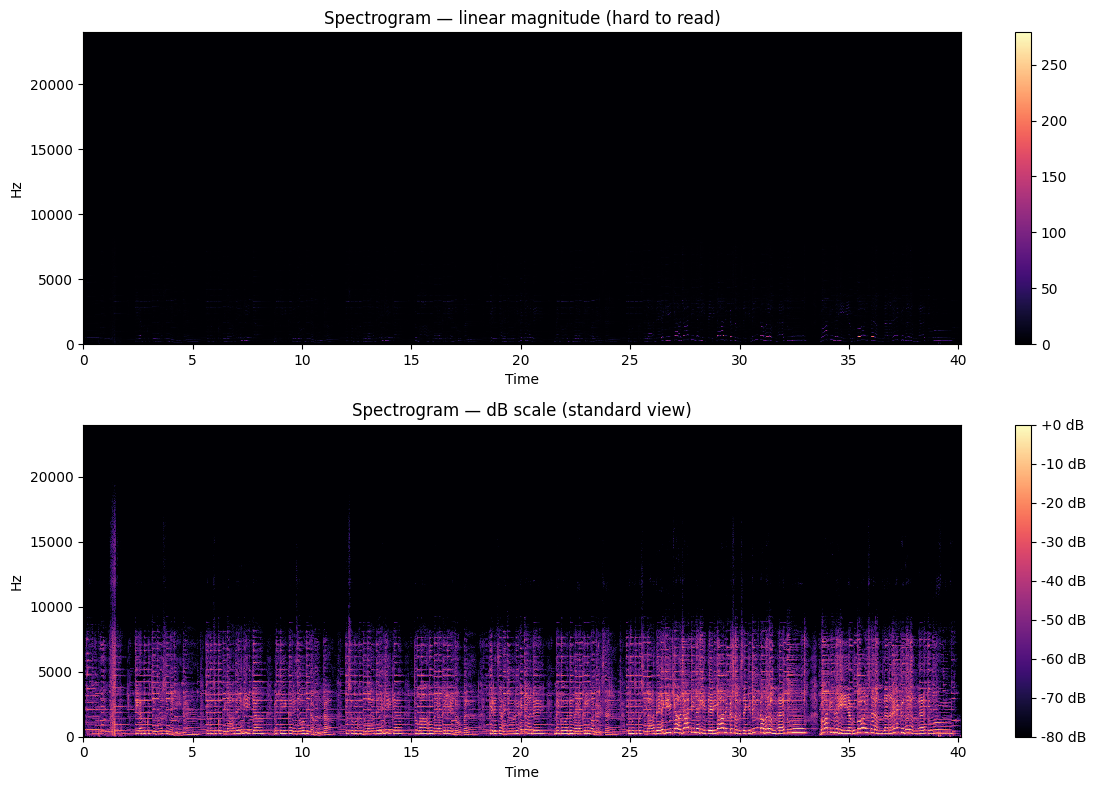

In [1]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt

y, sr = librosa.load("sample1.mp3", sr=None)

# --- Compute STFT ---
n_fft     = 2048   # window size — controls freq resolution
hop_length = 512   # step between windows — controls time resolution
window    = 'hann' # shape of the window (reduces edge artifacts)

D = librosa.stft(y, n_fft=n_fft, hop_length=hop_length, window=window)
# D is complex: shape = (1 + n_fft/2, n_frames) = (1025, ~3752 for your file)

# --- Get magnitude (ignore phase for visualization) ---
magnitude = np.abs(D)            # shape: (1025, n_frames)
print(f"Spectrogram shape: {magnitude.shape}")
print(f"Freq bins : {magnitude.shape[0]}  → each bin = {sr/n_fft:.1f} Hz wide")
print(f"Time frames: {magnitude.shape[1]} → each frame = {hop_length/sr*1000:.1f} ms")

# --- Convert to dB scale (log) for visualization ---
# Raw magnitude values are tiny (0.001 to 10), hard to see
# dB scale makes quiet and loud both visible
S_db = librosa.amplitude_to_db(magnitude, ref=np.max)
# Now values range from 0 dB (loudest) down to about -80 dB (silence)

# --- Plot ---
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Linear scale
img1 = librosa.display.specshow(magnitude, sr=sr, hop_length=hop_length,
                                 x_axis='time', y_axis='hz', ax=axes[0])
axes[0].set_title("Spectrogram — linear magnitude (hard to read)")
fig.colorbar(img1, ax=axes[0])

# dB scale (what you normally use)
img2 = librosa.display.specshow(S_db, sr=sr, hop_length=hop_length,
                                 x_axis='time', y_axis='hz', ax=axes[1],
                                 cmap='magma')
axes[1].set_title("Spectrogram — dB scale (standard view)")
fig.colorbar(img2, ax=axes[1], format="%+2.0f dB")

plt.tight_layout()
plt.show()